# Kernel Support Vector Machine

A **Support Vector Machine (SVM)** is a supervised binary classifier that finds the maximum-margin separating hyperplane between two classes. When classes are not linearly separable in the input space, the **kernel trick** implicitly maps data to a high-dimensional (or infinite-dimensional) feature space where linear separation becomes possible — without ever computing the coordinates of the mapping.

## Hard and soft margin primal

Given training data $(x_i, y_i)$ with $y_i \in \{-1, +1\}$, the **hard-margin SVM** maximises the geometric margin $\frac{2}{\|w\|}$ subject to correct classification:

$$
\min_{w, b} \frac{1}{2}\|w\|^2 \quad \text{s.t.} \quad y_i\bigl(w^\top \phi(x_i) + b\bigr) \geq 1 \quad \forall i.
$$

The **soft-margin** relaxation (C-SVM) introduces slack variables $\xi_i \geq 0$ and penalises margin violations:

$$
\min_{w, b, \xi} \frac{1}{2}\|w\|^2 + C\sum_i \xi_i \quad \text{s.t.} \quad y_i(w^\top\phi(x_i)+b) \geq 1 - \xi_i,\; \xi_i \geq 0.
$$

## Dual and kernel representation

Via Lagrangian duality, the primal converts to the **dual problem**:

$$
\max_{\alpha} \sum_i \alpha_i - \frac{1}{2}\sum_{i,j} \alpha_i \alpha_j y_i y_j K(x_i, x_j), \quad 0 \leq \alpha_i \leq C, \quad \sum_i \alpha_i y_i = 0.
$$

The decision function is $f(x) = \sum_i \alpha_i y_i K(x_i, x) + b$, where only the **support vectors** (points with $\alpha_i > 0$) contribute.

## RBF kernel

The **Radial Basis Function (RBF)** kernel corresponds to an infinite-dimensional feature space:

$$
K(x, z) = \exp\!\left(-\frac{\|x - z\|^2}{2\sigma^2}\right).
$$

The bandwidth $\sigma$ (or equivalently $\gamma = 1/(2\sigma^2)$) controls the reach of each support vector: small $\sigma$ gives a highly local classifier, large $\sigma$ approaches a linear boundary.

This notebook:
- visualises decision boundaries, margins, and support vectors for both linear and RBF kernels;
- compares the two classifiers on non-linearly-separable data;
- sweeps over the regularisation parameter $C$ and the bandwidth $\gamma$ interactively.

## Environment

Standard scientific stack plus `scikit-learn` for the SVM solver.

In [1]:
import numpy as np
import matplotlib
if 'get_ipython' not in globals():
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.svm import SVC
from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.preprocessing import StandardScaler
from ipywidgets import interact, FloatLogSlider, FloatSlider

plt.rcParams['figure.dpi'] = 110
rng = np.random.default_rng(42)

## Helper: decision boundary plot

We define a utility function that evaluates the SVM decision function on a fine grid and draws the separating hyperplane ($f=0$), the margin bands ($f=\pm 1$), and highlights the support vectors — the training points for which $\alpha_i > 0$.

In [2]:
def plot_svm_boundary(ax, clf, X, y, title='', h=0.02):
    """Draw decision boundary, margin, support vectors on ax."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    cmap_bg = ListedColormap(['#FFAAAA', '#AAAAFF'])
    ax.contourf(xx, yy, np.sign(Z), alpha=0.25, cmap=cmap_bg, levels=[-1.5, 0, 1.5])
    ax.contour(xx, yy, Z, levels=[-1, 0, 1],
               linestyles=['--', '-', '--'],
               colors=['#CC0000', '#000000', '#0000CC'],
               linewidths=[1.2, 2.0, 1.2])

    colors = ['#CC2222', '#2222CC']
    for cls, c in zip([-1, 1], colors):
        mask = y == cls
        ax.scatter(X[mask, 0], X[mask, 1], c=c, s=28, edgecolors='k',
                   linewidths=0.5, zorder=3)

    sv = clf.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=120, facecolors='none',
               edgecolors='k', linewidths=1.8, zorder=4, label=f'SVs ({len(sv)})')
    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
    ax.set_title(title, fontsize=10)
    ax.legend(loc='upper right', fontsize=8)

## Linear vs RBF kernel on two-moons data

The **two-moons** dataset is a canonical non-linearly-separable benchmark. A linear classifier produces a straight decision boundary that misclassifies many points, whereas the RBF kernel yields a smooth curved boundary adapted to the manifold structure.

We train both classifiers with $C = 1$ and display:
- background shading: predicted class;
- solid black contour: decision boundary $f(x) = 0$;
- dashed contours: margin planes $f(x) = \pm 1$;
- circled points: support vectors.

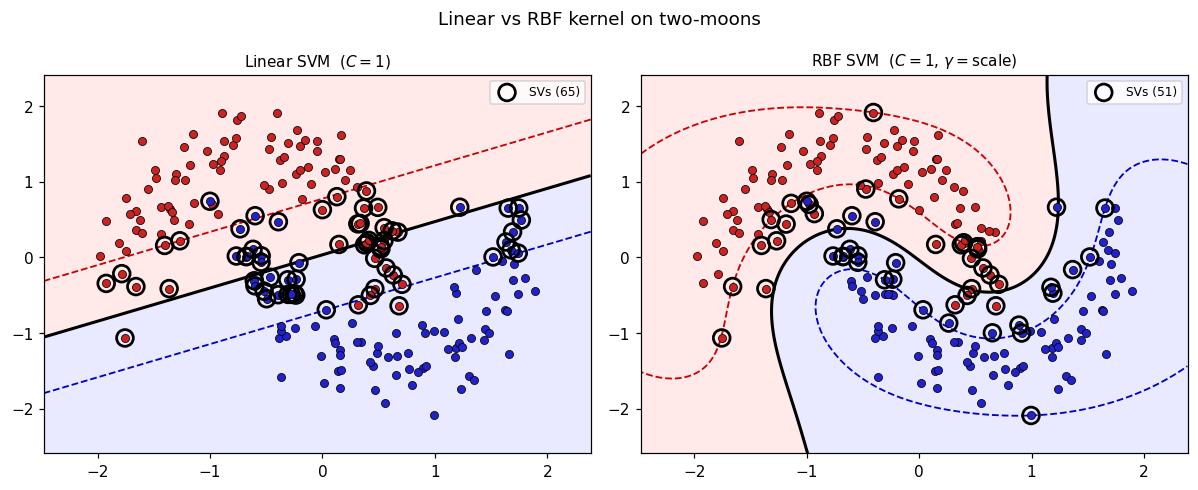

Saved linear_vs_rbf.png


In [3]:
X_moon, y_moon = make_moons(n_samples=200, noise=0.15, random_state=0)
sc = StandardScaler()
X_moon = sc.fit_transform(X_moon)
y_moon = 2 * y_moon - 1  # convert to {-1, +1}

clf_lin = SVC(kernel='linear', C=1.0).fit(X_moon, y_moon)
clf_rbf = SVC(kernel='rbf',    C=1.0, gamma='scale').fit(X_moon, y_moon)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_svm_boundary(axes[0], clf_lin, X_moon, y_moon,
                  title='Linear SVM  ($C=1$)')
plot_svm_boundary(axes[1], clf_rbf, X_moon, y_moon,
                  title='RBF SVM  ($C=1$, $\\gamma=\\text{scale}$)')
fig.suptitle('Linear vs RBF kernel on two-moons', fontsize=12)
plt.tight_layout()
plt.show()
plt.savefig('linear_vs_rbf.png', bbox_inches='tight')
plt.close()
print('Saved linear_vs_rbf.png')

## Effect of regularisation $C$

The regularisation parameter $C$ trades off margin width against training error. For **large $C$** the optimiser tries hard to classify every training point correctly (small slack), producing a narrow margin and potentially many support vectors. For **small $C$** the margin is wide but more training errors are tolerated.

Mathematically, increasing $C$ shifts weight from the $\frac{1}{2}\|w\|^2$ regulariser toward the empirical loss $\sum_i \xi_i$, making the boundary more complex.

The panel below shows four values $C \in \{0.1, 1, 10, 100\}$ on circles data.

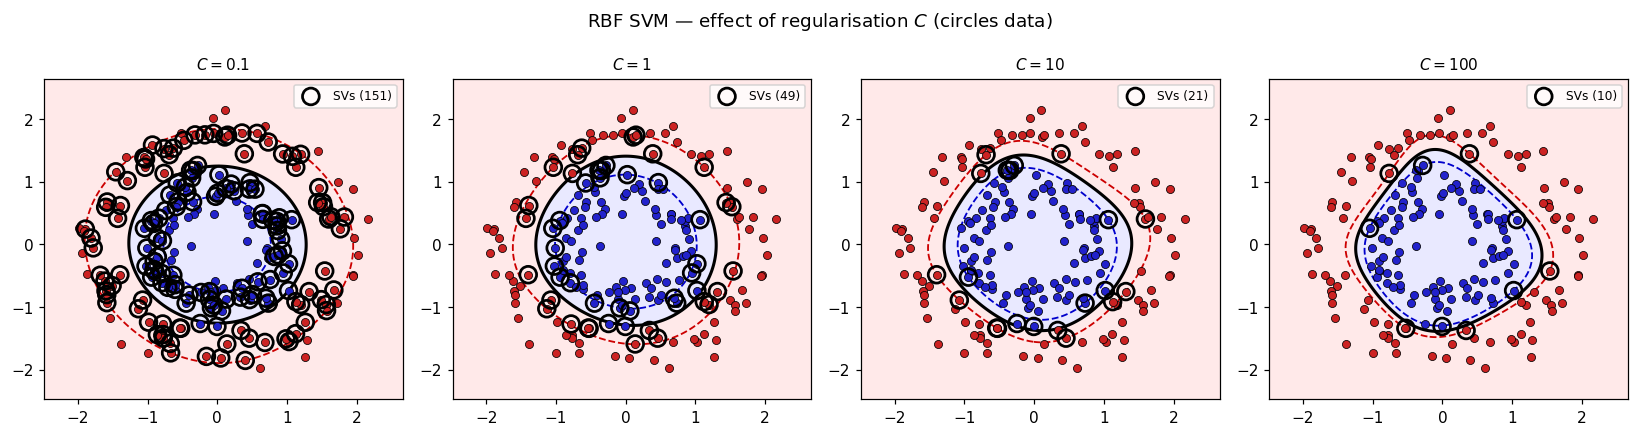

Saved svm_C_sweep.png


In [4]:
X_circ, y_circ = make_circles(n_samples=200, noise=0.12, factor=0.5, random_state=1)
X_circ = StandardScaler().fit_transform(X_circ)
y_circ = 2 * y_circ - 1

C_vals = [0.1, 1, 10, 100]
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, C in zip(axes, C_vals):
    clf = SVC(kernel='rbf', C=C, gamma='scale').fit(X_circ, y_circ)
    plot_svm_boundary(ax, clf, X_circ, y_circ, title=f'$C={C}$')
fig.suptitle('RBF SVM — effect of regularisation $C$ (circles data)', fontsize=12)
plt.tight_layout()
plt.show()
plt.savefig('svm_C_sweep.png', bbox_inches='tight')
plt.close()
print('Saved svm_C_sweep.png')

## Effect of bandwidth $\gamma$

The RBF kernel parameter $\gamma = 1/(2\sigma^2)$ controls the spatial reach of each support vector:

- **Small $\gamma$** (large $\sigma$): each support vector influences a wide region, producing a smooth globally-shaped boundary.
- **Large $\gamma$** (small $\sigma$): influence is very local; the boundary wraps tightly around individual training points, potentially overfitting.

This is directly analogous to the bandwidth in kernel density estimation.

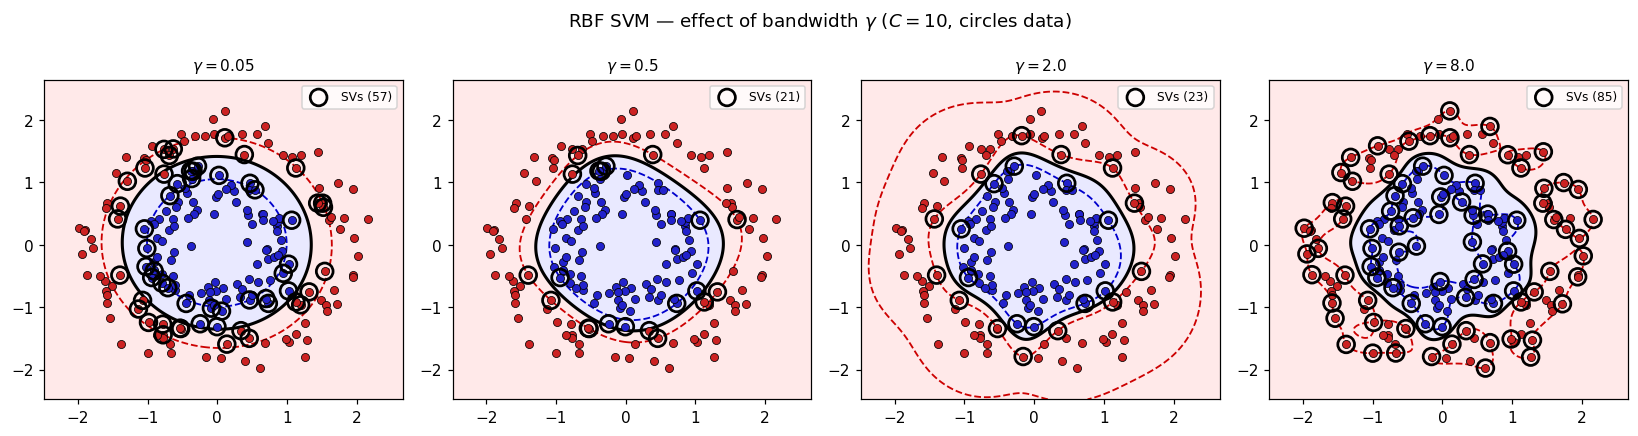

Saved svm_gamma_sweep.png


In [5]:
gamma_vals = [0.05, 0.5, 2.0, 8.0]
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, g in zip(axes, gamma_vals):
    clf = SVC(kernel='rbf', C=10, gamma=g).fit(X_circ, y_circ)
    plot_svm_boundary(ax, clf, X_circ, y_circ, title=f'$\\gamma={g}$')
fig.suptitle('RBF SVM — effect of bandwidth $\\gamma$ ($C=10$, circles data)', fontsize=12)
plt.tight_layout()
plt.show()
plt.savefig('svm_gamma_sweep.png', bbox_inches='tight')
plt.close()
print('Saved svm_gamma_sweep.png')

## Support vector distribution

On the dual side, the **dual coefficients** $\hat{\alpha}_i = \alpha_i y_i$ satisfy $|\hat{\alpha}_i| \leq C$. A support vector with $|\hat{\alpha}_i| = C$ is a **bounded support vector** (lies inside the margin); one with $0 < |\hat{\alpha}_i| < C$ is **free** (exactly on the margin hyperplane).

Plotting the sorted magnitude of dual coefficients reveals how many points are active and how sharply they concentrate near the bound.

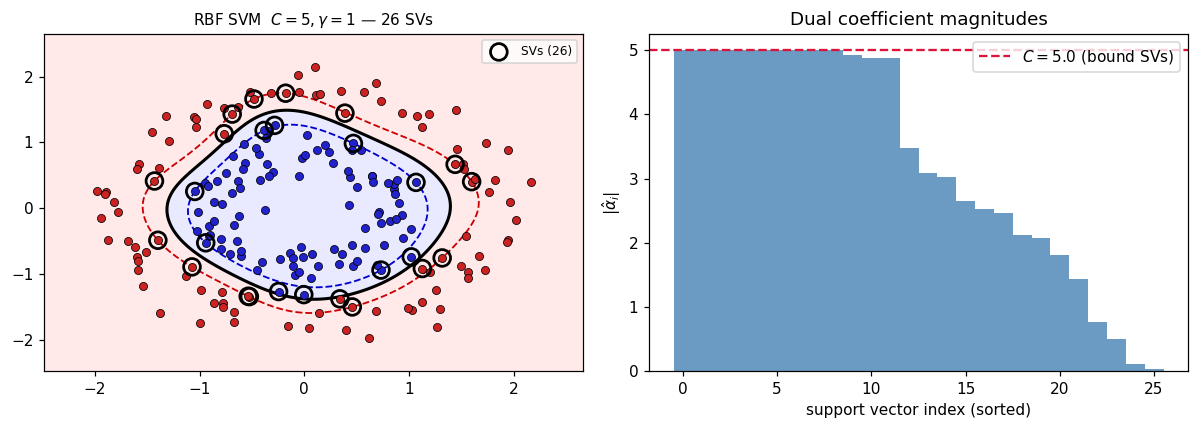

Saved svm_dual.png


In [6]:
clf_main = SVC(kernel='rbf', C=5.0, gamma=1.0).fit(X_circ, y_circ)
dual = np.abs(clf_main.dual_coef_[0])
dual_sorted = np.sort(dual)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

plot_svm_boundary(axes[0], clf_main, X_circ, y_circ,
                  title=f'RBF SVM  $C=5, \\gamma=1$ — {len(dual)} SVs')

axes[1].bar(np.arange(len(dual_sorted)), dual_sorted,
            color='steelblue', alpha=0.8, width=1.0)
axes[1].axhline(clf_main.C, color='crimson', ls='--', lw=1.5,
                label=f'$C = {clf_main.C}$ (bound SVs)')
axes[1].set_xlabel('support vector index (sorted)')
axes[1].set_ylabel(r'$|\hat{\alpha}_i|$')
axes[1].set_title('Dual coefficient magnitudes')
axes[1].legend()

plt.tight_layout()
plt.show()
plt.savefig('svm_dual.png', bbox_inches='tight')
plt.close()
print('Saved svm_dual.png')

## Kernel matrix visualisation

The RBF kernel matrix $K_{ij} = \exp(-\gamma\|x_i - x_j\|^2)$ encodes pairwise similarity. Points close in input space have $K_{ij}\approx 1$; distant points have $K_{ij}\approx 0$. After sorting by class label, the block structure of the matrix reveals how well the kernel separates the two classes.

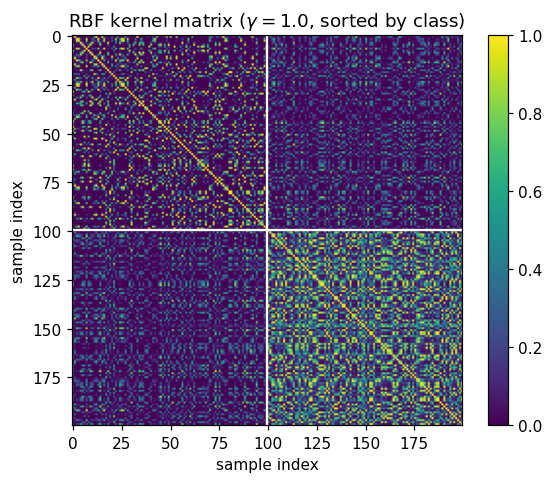

Saved svm_kernel_matrix.png


In [7]:
gamma_show = 1.0
sort_idx = np.argsort(y_circ)
Xs = X_circ[sort_idx]
K = np.exp(-gamma_show * np.sum((Xs[:, None] - Xs[None, :])**2, axis=-1))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(K, origin='upper', cmap='viridis', vmin=0, vmax=1)
n_neg = np.sum(y_circ == -1)
ax.axhline(n_neg - 0.5, color='white', lw=1.5)
ax.axvline(n_neg - 0.5, color='white', lw=1.5)
ax.set_title(f'RBF kernel matrix ($\\gamma={gamma_show}$, sorted by class)')
ax.set_xlabel('sample index'); ax.set_ylabel('sample index')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()
plt.savefig('svm_kernel_matrix.png', bbox_inches='tight')
plt.close()
print('Saved svm_kernel_matrix.png')

## Interactive explorer

The widget below lets you sweep the regularisation $C$ and bandwidth $\gamma$ in real time on the two-moons dataset and immediately observe the resulting decision boundary and support vector count.

## Static snapshot

For automated execution contexts, a representative static snapshot is saved below.

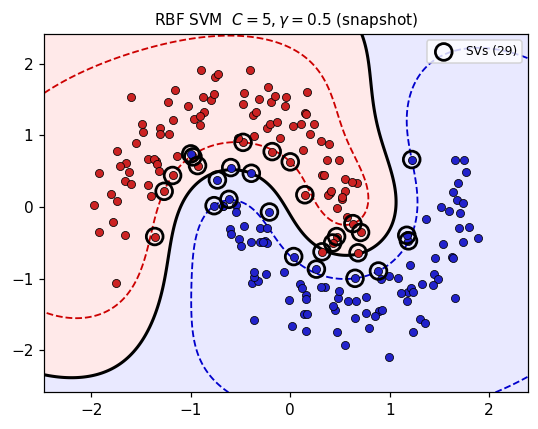

Saved snippet.png


In [8]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    clf_snap = SVC(kernel='rbf', C=5.0, gamma=0.5).fit(X_moon, y_moon)
    fig, ax = plt.subplots(figsize=(5, 4))
    plot_svm_boundary(ax, clf_snap, X_moon, y_moon,
                      title='RBF SVM  $C=5, \\gamma=0.5$ (snapshot)')
    plt.tight_layout()
    plt.show()
    plt.savefig('snippet.png', bbox_inches='tight')
    plt.close()
    print('Saved snippet.png')

## Takeaways

- The **kernel trick** lets SVMs find nonlinear boundaries without explicitly computing high-dimensional feature maps; only kernel evaluations $K(x_i, x_j)$ are needed.
- The **dual formulation** ensures that the decision function depends only on a sparse set of **support vectors** — points near or inside the margin.
- The RBF bandwidth $\gamma$ and regularisation $C$ must be jointly tuned: large $\gamma$ with large $C$ leads to overfitting; small $\gamma$ with small $C$ to underfitting.
- The kernel matrix structure directly reveals class separability: a well-tuned RBF kernel produces a near-block-diagonal Gram matrix.

## Bibliography

- Boser, B. E., Guyon, I. M., and Vapnik, V. N. (1992). A training algorithm for optimal margin classifiers. *COLT 1992*.
- Cortes, C. and Vapnik, V. (1995). Support-vector networks. *Machine Learning*, 20(3), 273–297.
- Schölkopf, B. and Smola, A. J. (2002). *Learning with Kernels*. MIT Press.
- Steinwart, I. and Christmann, A. (2008). *Support Vector Machines*. Springer.
- Cristianini, N. and Shawe-Taylor, J. (2000). *An Introduction to Support Vector Machines*. Cambridge University Press.